In [ ]:
!git clone https://github.com/wmivikas/ml-molecular-solubility.git

fatal: destination path 'ml-molecular-solubility' already exists and is not an empty directory.


In [ ]:
# Core
import time
import warnings
warnings.filterwarnings("ignore")

# Data & Math
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import pearsonr, spearmanr, randint, uniform

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Sklearn - Data Handling
from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer

# Sklearn - Feature Selection
from sklearn.feature_selection import SelectKBest, f_regression

# Sklearn - Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Sklearn - Metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Pipeline
from sklearn.pipeline import Pipeline

# Saving Models
import joblib
RANDOM_STATE=42

In [ ]:
df = pd.read_csv("/content/ml-molecular-solubility/curated-solubility-dataset.csv")

In [ ]:
df.head(3)

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782,202.661065


In [ ]:
# Quick EDA
print("\nShape:", df.shape)
print("\nMissing per column:\n", df.isnull().sum())
print("\nTarget stats:\n", df['Solubility'].describe())



Shape: (9982, 26)

Missing per column:
 ID                     0
Name                   0
InChI                  0
InChIKey               0
SMILES                 0
Solubility             0
SD                     0
Ocurrences             0
Group                  0
MolWt                  0
MolLogP                0
MolMR                  0
HeavyAtomCount         0
NumHAcceptors          0
NumHDonors             0
NumHeteroatoms         0
NumRotatableBonds      0
NumValenceElectrons    0
NumAromaticRings       0
NumSaturatedRings      0
NumAliphaticRings      0
RingCount              0
TPSA                   0
LabuteASA              0
BalabanJ               0
BertzCT                0
dtype: int64

Target stats:
 count    9982.000000
mean       -2.889909
std         2.368154
min       -13.171900
25%        -4.326325
50%        -2.618173
75%        -1.209735
max         2.137682
Name: Solubility, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df['Solubility'].dropna(), bins=40)
plt.title("Solubility distribution")
plt.xlabel("Solubility"); plt.ylabel("Count")
plt.show()


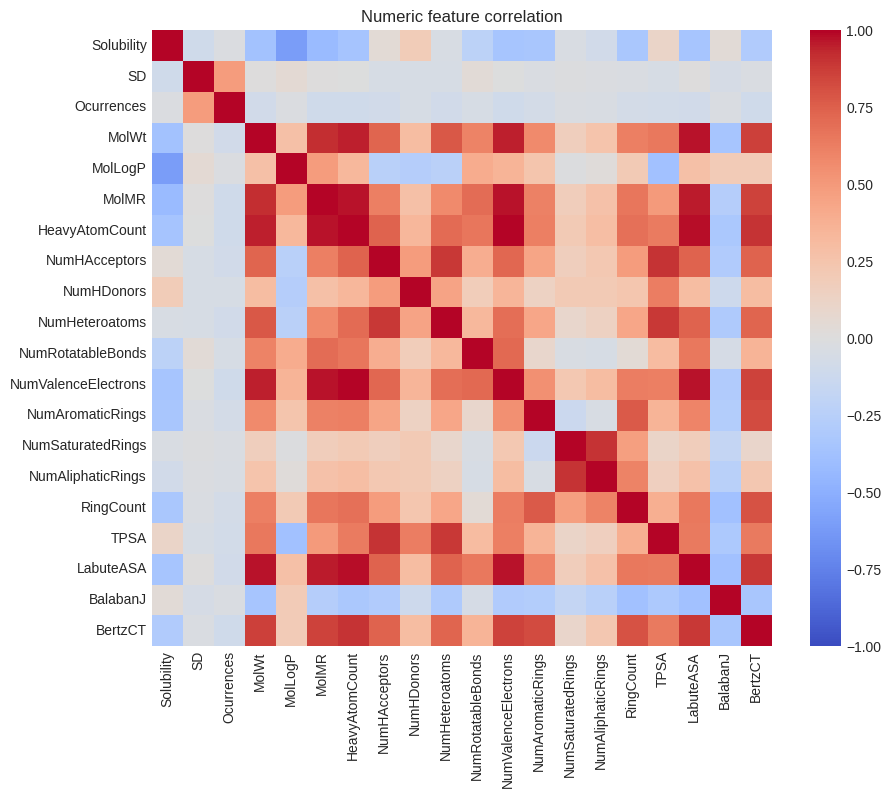

In [ ]:
numeric = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10,8))
corr = numeric.corr()
sns.heatmap(corr, vmax=1, vmin=-1, cmap='coolwarm', fmt=".2f")
plt.title("Numeric feature correlation")
plt.show()

In [ ]:
drop_cols = ['ID','Name','InChI','InChIKey','SMILES','Group']  # adjust if columns differ
features = [c for c in df.columns if c not in drop_cols + ['Solubility']]

In [ ]:
features

['SD',
 'Ocurrences',
 'MolWt',
 'MolLogP',
 'MolMR',
 'HeavyAtomCount',
 'NumHAcceptors',
 'NumHDonors',
 'NumHeteroatoms',
 'NumRotatableBonds',
 'NumValenceElectrons',
 'NumAromaticRings',
 'NumSaturatedRings',
 'NumAliphaticRings',
 'RingCount',
 'TPSA',
 'LabuteASA',
 'BalabanJ',
 'BertzCT']

In [ ]:
features

['SD',
 'Ocurrences',
 'MolWt',
 'MolLogP',
 'MolMR',
 'HeavyAtomCount',
 'NumHAcceptors',
 'NumHDonors',
 'NumHeteroatoms',
 'NumRotatableBonds',
 'NumValenceElectrons',
 'NumAromaticRings',
 'NumSaturatedRings',
 'NumAliphaticRings',
 'RingCount',
 'TPSA',
 'LabuteASA',
 'BalabanJ',
 'BertzCT']

In [ ]:
target_corr = numeric.corr()['Solubility'].sort_values(ascending=False)
print(target_corr)

Solubility             1.000000
NumHDonors             0.193066
TPSA                   0.111662
NumHAcceptors          0.040020
BalabanJ               0.037329
Ocurrences            -0.021133
NumSaturatedRings     -0.037794
NumHeteroatoms        -0.040432
NumAliphaticRings     -0.087706
SD                    -0.099553
NumRotatableBonds     -0.222040
BertzCT               -0.289403
RingCount             -0.329599
NumAromaticRings      -0.343257
NumValenceElectrons   -0.346369
LabuteASA             -0.349497
HeavyAtomCount        -0.352748
MolWt                 -0.368032
MolMR                 -0.424452
MolLogP               -0.608580
Name: Solubility, dtype: float64


In [ ]:
selected = target_corr[abs(target_corr) > 0.3]
print("Selected features:", selected.index.tolist())


Selected features: ['Solubility', 'RingCount', 'NumAromaticRings', 'NumValenceElectrons', 'LabuteASA', 'HeavyAtomCount', 'MolWt', 'MolMR', 'MolLogP']


In [ ]:

X_cols = [col for col in selected.index.tolist() if col != 'Solubility']
X = df[X_cols].copy()
y = df['Solubility'].copy()

In [ ]:
X

,RingCount,NumAromaticRings,NumValenceElectrons,LabuteASA,HeavyAtomCount,MolWt,MolMR,MolLogP
0,0.0,0.0,142.0,158.520601,23.0,392.510,102.4454,3.95810
1,3.0,2.0,62.0,75.183563,13.0,169.183,51.9012,2.40550
2,1.0,1.0,46.0,58.261134,9.0,140.569,36.8395,2.15250
3,6.0,6.0,264.0,323.755434,53.0,756.226,200.7106,8.11610
4,6.0,2.0,164.0,183.183268,31.0,422.525,119.0760,2.48540
...,...,...,...,...,...,...,...,...
9977,1.0,1.0,106.0,115.300645,19.0,264.369,78.6762,2.61700
9978,4.0,1.0,170.0,182.429237,32.0,444.440,109.5409,-0.21440
9979,1.0,1.0,60.0,67.685405,11.0,150.221,46.9328,2.82402
9980,2.0,2.0,180.0,198.569223,33.0,454.611,131.6560,5.09308


In [ ]:
X.describe()

,RingCount,NumAromaticRings,NumValenceElectrons,LabuteASA,HeavyAtomCount,MolWt,MolMR,MolLogP
count,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000
mean,1.515929,1.068323,94.243438,108.912586,17.374674,266.665946,66.794594,1.979167
std,1.644334,1.309427,64.748563,76.462726,12.241536,184.179024,46.523021,3.517738
min,0.000000,0.000000,0.000000,7.504228,1.000000,9.012000,0.000000,-40.873200
25%,0.000000,0.000000,58.000000,66.623721,11.000000,162.276000,40.602475,0.619750
50%,1.000000,1.000000,82.000000,93.299873,15.000000,228.682000,58.633400,1.949220
75%,2.000000,2.000000,112.000000,129.118374,21.000000,320.436000,81.938000,3.419030
max,36.000000,35.000000,2012.000000,2230.685124,388.000000,5299.456000,1419.351700,68.541140


In [ ]:
y

,Solubility
0,-3.616127
1,-3.254767
2,-2.177078
3,-3.924409
4,-4.662065
...,...
9977,-3.010000
9978,-2.930000
9979,-2.190000
9980,-3.980000


In [ ]:
# Replace df with your dataframe name
selected_features = [
    'MolLogP',
    'MolMR',
   'MolWt',


  'NumAromaticRings'
]

X = df[selected_features]
y = df['Solubility']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42
    ))
])


In [ ]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=800, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
y_pred = pipeline.predict(X_test)


In [ ]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5 # Calculate RMSE by taking the square root
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 1.1910060731232222
MAE: 0.8378514694980219
R²: 0.7385090841073148


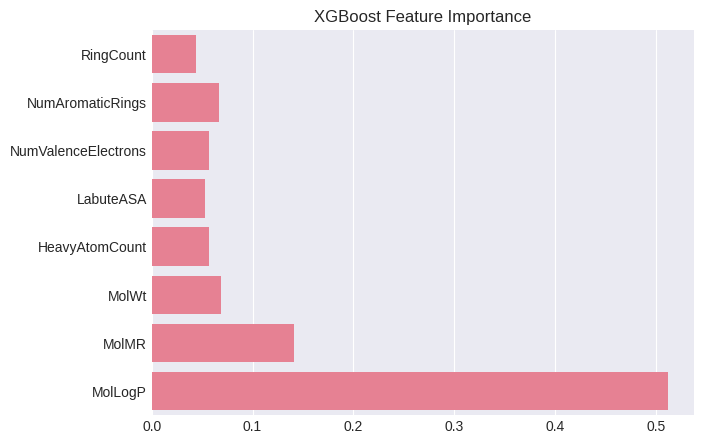

In [ ]:
model = pipeline.named_steps['model']
importance = model.feature_importances_

plt.figure(figsize=(7,5))
sns.barplot(x=importance, y=selected_features)
plt.title("XGBoost Feature Importance")
plt.show()


In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [ ]:
# y_pred = pipe_rf.predict(X_test)
y_pred = pipeline.predict(X_test)

In [ ]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 1.2286688886575619
MAE: 0.876286348215794
R²: 0.7217095024192497


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_transformed, test_size=0.2, random_state=42
)

Training Linear Regression...
  R2 Score: 0.5049
Training Ridge Regression...
  R2 Score: 0.5052
Training Decision Tree...
  R2 Score: 0.5467
Training KNN...
  R2 Score: 0.7136
Training Random Forest...
  R2 Score: 0.7380


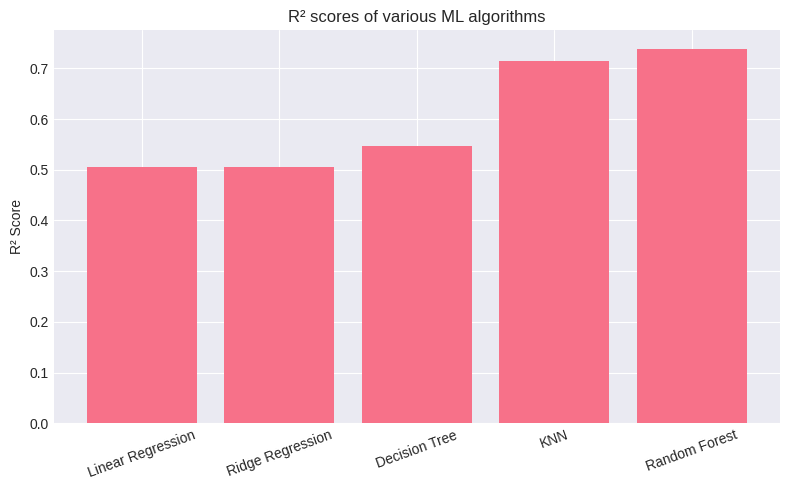

In [ ]:



# Define models with scaling pipeline

pipelines = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),   # scaling optional here
        ("model", DecisionTreeRegressor(random_state=42))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),   # scaling optional here
        ("model", RandomForestRegressor(
            n_estimators=200, random_state=42))
    ])
}


# Train, predict, collect R² scores

r2_scores = {}

for name, pipe in pipelines.items():
    print(f"Training {name}...")
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    r2 = r2_score(y_test, preds)
    r2_scores[name] = r2
    print(f"  R2 Score: {r2:.4f}")

# Plot results

plt.figure(figsize=(8,5))
plt.bar(r2_scores.keys(), r2_scores.values())
plt.xticks(rotation=20)
plt.ylabel("R² Score")
plt.title("R² scores of various ML algorithms")
plt.tight_layout()
plt.show()



🔍 Tuning: Linear Regression
  ✅ Best R2: 0.5049
  🎯 Best Params: {'model__fit_intercept': True}

🔍 Tuning: Ridge Regression
  ✅ Best R2: 0.5074
  🎯 Best Params: {'model__alpha': 10}

🔍 Tuning: Decision Tree
  ✅ Best R2: 0.6756
  🎯 Best Params: {'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}

🔍 Tuning: KNN
  ✅ Best R2: 0.7434
  🎯 Best Params: {'model__n_neighbors': 11, 'model__weights': 'distance'}

🔍 Tuning: Random Forest
  ✅ Best R2: 0.7377
  🎯 Best Params: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__n_estimators': 300}


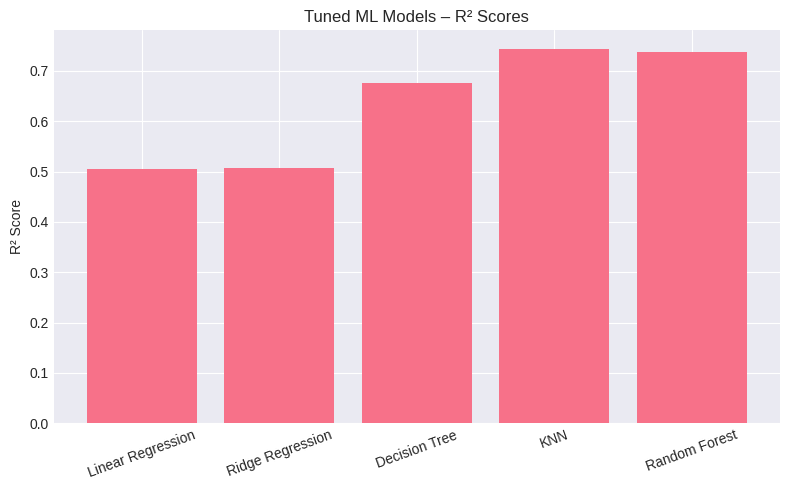


============== BEST HYPERPARAMETERS ==============

Linear Regression:
{'model__fit_intercept': True}

Ridge Regression:
{'model__alpha': 10}

Decision Tree:
{'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}

KNN:
{'model__n_neighbors': 11, 'model__weights': 'distance'}

Random Forest:
{'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__n_estimators': 300}


In [ ]:


# Hyperparameter grids

param_grids = {
    "Linear Regression": {
        "model__fit_intercept": [True, False]
    },

    "Ridge Regression": {
        "model__alpha": [0.1, 1, 10, 50, 100]
    },

    "Decision Tree": {
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 5]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"]
    },

    "Random Forest": {
        "model__n_estimators": [300],
        "model__max_depth": [None,  20],
        "model__min_samples_leaf": [2]}

}


# Pipelines for each model

pipelines = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),

    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor())
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(random_state=42))
    ])
}


# Grid search for each model

r2_scores = {}
best_params = {}

for name, pipeline in pipelines.items():
    print(f"Tuning: {name}")

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    preds = grid.predict(X_test)

    r2 = r2_score(y_test, preds)
    r2_scores[name] = r2
    best_params[name] = grid.best_params_

    print(f"  Best R2: {r2:.4f}")
    print(f" Best Params: {grid.best_params_}")


# Plot R² comparison

plt.figure(figsize=(8,5))
plt.bar(r2_scores.keys(), r2_scores.values())
plt.xticks(rotation=20)
plt.ylabel("R² Score")
plt.title("Tuned ML Models – R² Scores")
plt.tight_layout()
plt.show()

# Show best hyperparameters for all models
print("\n BEST HYPERPARAMETERS")
for name, params in best_params.items():
    print(f"\n{name}:")
    print(params)


# Randomized_search_pipeline


>>> Running RandomizedSearchCV for: Linear Regression
Fitting 5 folds for each of 2 candidates, totalling 10 fits
  Time (s): 6.3
  Best CV R2: 0.4486
  Test R2: 0.5049
  Best params: {'model__fit_intercept': True}

>>> Running RandomizedSearchCV for: Ridge Regression
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Time (s): 2.9
  Best CV R2: 0.4492
  Test R2: 0.5080
  Best params: {'model__alpha': np.float64(13.950386065204183)}

>>> Running RandomizedSearchCV for: Decision Tree
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Time (s): 9.0
  Best CV R2: 0.6760
  Test R2: 0.6695
  Best params: {'model__max_depth': 9, 'model__min_samples_leaf': 8, 'model__min_samples_split': 12}

>>> Running RandomizedSearchCV for: KNN
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Time (s): 10.3
  Best CV R2: 0.7262
  Test R2: 0.7454
  Best params: {'model__n_neighbors': 17, 'model__p': 2, 'model__weights': 'distance'}

>>> Running RandomizedSearchCV fo

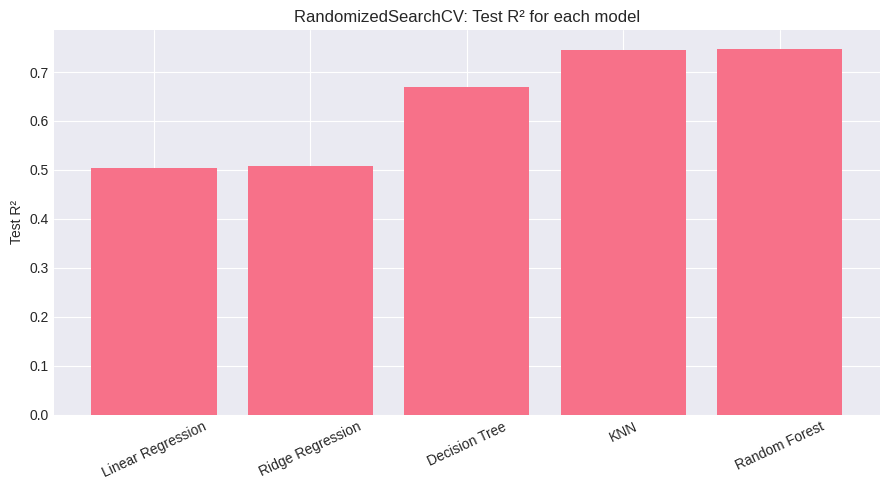


Best model by test R²: Random Forest -> 0.7478
Saved best_randomized_model.joblib


In [ ]:

RANDOM_STATE = 42
CV = 5
N_ITER = 30   # number of random parameter settings to try (increase for better search)


# Pipelines

pipelines = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge Regression": Pipeline([("scaler", StandardScaler()), ("model", Ridge(random_state=RANDOM_STATE))]),
    "Decision Tree": Pipeline([("scaler", StandardScaler()), ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsRegressor())]),
    "Random Forest": Pipeline([("scaler", StandardScaler()), ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
}

# Parameter distributions for RandomizedSearchCV

param_distributions = {
    "Linear Regression": {
        "model__fit_intercept": [True, False]
    },

    "Ridge Regression": {
        # search alpha on log scale
        "model__alpha": uniform(loc=1e-3, scale=100.0)  # uniform between 0.001 and 100.001
    },

    "Decision Tree": {
        "model__max_depth": randint(2, 40),            # integer depths 2..39
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10)
    },

    "KNN": {
        "model__n_neighbors": randint(1, 31),          # 1..30
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]                             # Manhattan (1) or Euclidean (2)
    },

    "Random Forest": {
        "model__n_estimators": randint(50, 500),
        "model__max_depth": randint(3, 50),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": ["auto", "sqrt", "log2", None]
    }
}


# Randomized search for each model

results = {}
best_estimators = {}
start_all = time.time()

for name, pipeline in pipelines.items():
    print(f"\n>>> Running RandomizedSearchCV for: {name}")
    dist = param_distributions.get(name, {})
    rs = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=dist,
        n_iter=N_ITER,
        cv=CV,
        scoring="r2",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )
    t0 = time.time()
    rs.fit(X_train, y_train)
    t1 = time.time()

    best = rs.best_estimator_
    preds = best.predict(X_test)
    test_r2 = r2_score(y_test, preds)

    print(f"  Time (s): {(t1-t0):.1f}")
    print(f"  Best CV R2: {rs.best_score_:.4f}")
    print(f"  Test R2: {test_r2:.4f}")
    print(f"  Best params: {rs.best_params_}")

    results[name] = {"cv_r2": rs.best_score_, "test_r2": test_r2, "time_s": (t1-t0)}
    best_estimators[name] = best

end_all = time.time()
print(f"\nTotal tuning time: {(end_all - start_all)/60:.2f} minutes")


# Plot test R²

names = list(results.keys())
test_scores = [results[n]["test_r2"] for n in names]

plt.figure(figsize=(9,5))
plt.bar(names, test_scores)
plt.xticks(rotation=25)
plt.ylabel("Test R²")
plt.title("RandomizedSearchCV: Test R² for each model")
plt.tight_layout()
plt.show()

# Optionally

import joblib
best_name = max(results.keys(), key=lambda n: results[n]["test_r2"])
print(f"\nBest model by test R²: {best_name} -> {results[best_name]['test_r2']:.4f}")
joblib.dump(best_estimators[best_name], "best_randomized_model.joblib")
print("Saved best_randomized_model.joblib")


In [ ]:
arget_corr = numeric.corr()

In [ ]:
arget_corr

,Solubility,SD,Ocurrences,MolWt,MolLogP,MolMR,HeavyAtomCount,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
Solubility,1.000000,-0.099553,-0.021133,-0.368032,-0.608580,-0.424452,-0.352748,0.040020,0.193066,-0.040432,-0.222040,-0.346369,-0.343257,-0.037794,-0.087706,-0.329599,0.111662,-0.349497,0.037329,-0.289403
SD,-0.099553,1.000000,0.489628,0.000316,0.052496,0.005535,-0.006657,-0.050575,-0.049584,-0.050257,0.036640,-0.000940,-0.025703,-0.013044,-0.016747,-0.031209,-0.051690,0.004100,-0.058347,-0.030728
Ocurrences,-0.021133,0.489628,1.000000,-0.089321,-0.017733,-0.093789,-0.097888,-0.093552,-0.050153,-0.091217,-0.052953,-0.095099,-0.070711,-0.025973,-0.033346,-0.077698,-0.080972,-0.086132,-0.028484,-0.093979
MolWt,-0.368032,0.000316,-0.089321,1.000000,0.274489,0.918897,0.950358,0.728544,0.300740,0.778160,0.607132,0.945888,0.570508,0.166785,0.256686,0.618948,0.653639,0.972633,-0.350478,0.860903
MolLogP,-0.608580,0.052496,-0.017733,0.274489,1.000000,0.489295,0.333832,-0.249365,-0.266122,-0.238849,0.400844,0.357257,0.249597,-0.008381,0.018135,0.210392,-0.377232,0.280342,0.199313,0.197622
MolMR,-0.424452,0.005535,-0.093789,0.918897,0.489295,1.000000,0.974646,0.617344,0.274044,0.576984,0.696115,0.973741,0.613457,0.179147,0.269113,0.661120,0.496881,0.956373,-0.269328,0.852327
HeavyAtomCount,-0.352748,-0.006657,-0.097888,0.950358,0.333832,0.974646,1.000000,0.737311,0.339465,0.710718,0.656378,0.992939,0.623851,0.203594,0.296704,0.687093,0.638169,0.983198,-0.322215,0.901773
NumHAcceptors,0.040020,-0.050575,-0.093552,0.728544,-0.249365,0.617344,0.737311,1.000000,0.492136,0.889812,0.395080,0.719298,0.438130,0.165544,0.222708,0.491738,0.900391,0.736286,-0.296685,0.741841
NumHDonors,0.193066,-0.049584,-0.050153,0.300740,-0.266122,0.274044,0.339465,0.492136,1.000000,0.452983,0.180429,0.346488,0.134581,0.207908,0.206509,0.239624,0.630250,0.301494,-0.110805,0.302379
NumHeteroatoms,-0.040432,-0.050257,-0.091217,0.778160,-0.238849,0.576984,0.710718,0.889812,0.452983,1.000000,0.330042,0.692642,0.432433,0.086571,0.144714,0.437176,0.886101,0.740770,-0.304440,0.734350


In [ ]:
arget_corr = np.abs(numeric.corr()['Solubility']).sort_values(ascending=False)

In [ ]:
arget_corr

,Solubility
Solubility,1.000000
MolLogP,0.608580
MolMR,0.424452
MolWt,0.368032
HeavyAtomCount,0.352748
LabuteASA,0.349497
NumValenceElectrons,0.346369
NumAromaticRings,0.343257
RingCount,0.329599
BertzCT,0.289403


In [ ]:
selected_features_n = [
    'MolLogP',
    'MolMR',
   'MolWt',
  'NumAromaticRings'
]

selected_features = [
    'MolLogP', 'MolMR', 'MolWt', 'HeavyAtomCount', 'LabuteASA',
    'NumValenceElectrons', 'NumAromaticRings', 'RingCount',
    'BertzCT', 'NumRotatableBonds', 'NumHDonors'
]

X = df[selected_features]
y = df['Solubility']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler1 = StandardScaler()
X_train_scaled_corr = scaler1.fit_transform(X_train[selected_features_n])
X_test_scaled_corr = scaler1.transform(X_test[selected_features_n])


# PCA (2 components)
pca = PCA(n_components=2)
pca_train = pca.fit_transform(X_train_scaled)
pca_test = pca.transform(X_test_scaled)

# Combine: features + PCA components
X_train_final = np.hstack([X_train_scaled, pca_train])
X_train_final_corr = np.hstack([X_train_scaled_corr, pca_train])

X_test_final = np.hstack([X_test_scaled, pca_test])
X_test_final_corr = np.hstack([X_test_scaled_corr, pca_test])



# Model (Random Forest)
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train_final, y_train)

# Predictions
y_pred = model.predict(X_test_final)



# Evaluation
rmse = mean_squared_error(y_test, y_pred)**0.5
mae = np.mean(np.abs(y_test - y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)


RMSE: 1.1576469995821375
MAE: 0.7955053026124468
R2 Score: 0.7529522202635736


In [ ]:
# Model (Random Forest)
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train_final_corr, y_train)

# Predictions
y_pred = model.predict(X_test_final_corr)

# Evaluation
rmse = mean_squared_error(y_test, y_pred)**0.5
mae = np.mean(np.abs(y_test - y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 1.1953021139730053
MAE: 0.8275174227790654
R2 Score: 0.7366192504136662


In [ ]:
rmse = mean_squared_error(y_test, y_pred)*0.5
mae = np.mean(np.abs(y_test - y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 0.7143735718341677
MAE: 0.8275174227790654
R2 Score: 0.7366192504136662


# Complete Results Metrics


In [ ]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred,)**0.5

def evaluate_model(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# Columns

all_descriptors = ['SD',
 'Ocurrences',
 'MolWt',
 'MolLogP',
 'MolMR',
 'HeavyAtomCount',
 'NumHAcceptors',
 'NumHDonors',
 'NumHeteroatoms',
 'NumRotatableBonds',
 'NumValenceElectrons',
 'NumAromaticRings',
 'NumSaturatedRings',
 'NumAliphaticRings',
 'RingCount',
 'TPSA',
 'LabuteASA',
 'BalabanJ',
 'BertzCT']


target_col = "Solubility"

# Define feature sets F1..F6
F_sets = {
    "F1_Full_19": all_descriptors,                       # F1: All 19 descriptors
    "F2_Corr_8": ["MolLogP", "MolMR", "MolWt", "LabuteASA",
                  "HeavyAtomCount", "NumValenceElectrons",
                  "NumAromaticRings", "RingCount"],       # F2: corr >= 0.30 (8)
    "F3_Corr_3": ["MolLogP", "MolMR", "MolWt"],         # F3: corr >= 0.35 (3)

    "F4_PCA_19": all_descriptors,                       # PCA computed later
    "F5_PCA_8": ["MolLogP", "MolMR", "MolWt", "LabuteASA",
                 "HeavyAtomCount", "NumValenceElectrons",
                 "NumAromaticRings", "RingCount"],       # PCA on the 8
    "F6_PCA_3": ["MolLogP", "MolMR", "MolWt"],         # PCA on the 3
}

# Models and hyperparameter distributions
models_and_params = {
    "Ridge": {
        "estimator": Ridge(random_state=RANDOM_STATE),
        "param_distributions": {
            "model__alpha": uniform(1e-3, 100)  # Ridge alpha range
        }
    },
    "DecisionTree": {
        "estimator": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "param_distributions": {
            "model__max_depth": randint(3, 30),
            "model__min_samples_split": randint(2, 20),
            "model__min_samples_leaf": randint(1, 10)
        }
    },
    "KNN": {
        "estimator": KNeighborsRegressor(),
        "param_distributions": {
            "model__n_neighbors": randint(1, 50),
            "model__weights": ["uniform", "distance"],
            "model__leaf_size": randint(10, 70)
        }
    },
    "RandomForest": {
        "estimator": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "param_distributions": {
            "model__n_estimators": randint(50, 400),
            "model__max_depth": randint(5, 50),
            "model__min_samples_leaf": randint(1, 10),
            "model__max_features": ["auto", "sqrt", "log2", 0.2, 0.5, 0.8]
        }
    }
}

# Prepare data

assert target_col in df.columns, f"Target column '{target_col}' not found in df"
for name, cols in F_sets.items():
    for c in cols:
        if c not in df.columns:
            raise ValueError(f"Column '{c}' required for {name} not found in df")

# Optional: target transform if highly skewed (Yeo-Johnson)
apply_target_transform = False  # set True if you want to transform target
if apply_target_transform:
    pt = PowerTransformer(method="yeo-johnson")
    df[target_col] = pt.fit_transform(df[[target_col]])

X_all = df.copy()

# Split once and reuse same split for fair comparison
X = df[all_descriptors]
y = df[target_col].values
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

results = []

# Loop over feature sets and models
for f_id, feat_list in F_sets.items():
    print(f"\n=== Running experiments for feature set: {f_id} ===")
    # Decide whether to apply PCA pipeline or raw features
    is_pca = f_id.startswith("F4_") or f_id.startswith("F5_") or f_id.startswith("F6_")

    # Build X_train and X_test for this feature set
    X_train = X_train_full[feat_list].copy()
    X_test = X_test_full[feat_list].copy()

    for model_name, mp in models_and_params.items():
        print(f"-> Model: {model_name}")
        # Pipeline: scaler -> (optional PCA) -> model
        steps = [("scaler", StandardScaler())]
        if is_pca:
            steps.append(("pca", PCA(n_components=2, random_state=RANDOM_STATE)))
            # note: PCA
        steps.append(("model", mp["estimator"]))
        pipe = Pipeline(steps)

        # Randomized search
        rs = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=mp["param_distributions"],
            n_iter=40,
            scoring="neg_root_mean_squared_error",  # optimize RMSE
            cv=5,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=0
        )
        rs.fit(X_train, y_train)

        # Best estimator predictions
        best_pipe = rs.best_estimator_
        y_pred = best_pipe.predict(X_test)
        metrics = evaluate_model(y_test, y_pred)

        # Record results
        res = {
            "feature_set": f_id,
            "model": model_name,
            "is_pca": is_pca,
            "best_params": rs.best_params_,
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "R2": metrics["R2"],
            "cv_best_score": -rs.best_score_  # because scoring was negative RMSE
        }
        results.append(res)

        # Save the best pipeline to disk
        outdir = "saved_models"
        os.makedirs(outdir, exist_ok=True)
        model_fname = os.path.join(outdir, f"{f_id}__{model_name}__best.pkl")
        joblib.dump(best_pipe, model_fname)
        print(f"    Saved best model to: {model_fname}")
        print(f"    Test RMSE: {metrics['RMSE']:.4f}, MAE: {metrics['MAE']:.4f}, R2: {metrics['R2']:.4f}")

# Collect results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["feature_set", "model"]).reset_index(drop=True)
results_df.to_csv("model_results_summary.csv", index=False)
print("\nAll experiments finished. Summary saved to model_results_summary.csv")



=== Running experiments for feature set: F1_Full_19 ===
-> Model: Ridge
    Saved best model to: saved_models/F1_Full_19__Ridge__best.pkl
    Test RMSE: 1.6430, MAE: 1.2033, R2: 0.5023
-> Model: DecisionTree
    Saved best model to: saved_models/F1_Full_19__DecisionTree__best.pkl
    Test RMSE: 1.2809, MAE: 0.9032, R2: 0.6975
-> Model: KNN
    Saved best model to: saved_models/F1_Full_19__KNN__best.pkl
    Test RMSE: 1.1694, MAE: 0.8141, R2: 0.7479
-> Model: RandomForest
    Saved best model to: saved_models/F1_Full_19__RandomForest__best.pkl
    Test RMSE: 1.0824, MAE: 0.7460, R2: 0.7840

=== Running experiments for feature set: F2_Corr_8 ===
-> Model: Ridge
    Saved best model to: saved_models/F2_Corr_8__Ridge__best.pkl
    Test RMSE: 1.6347, MAE: 1.2407, R2: 0.5074
-> Model: DecisionTree
    Saved best model to: saved_models/F2_Corr_8__DecisionTree__best.pkl
    Test RMSE: 1.3407, MAE: 0.9431, R2: 0.6686
-> Model: KNN
    Saved best model to: saved_models/F2_Corr_8__KNN__best.pkl


In [ ]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred,)**0.5

def evaluate_model(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# Columns

all_descriptors = ['SD',
 'Ocurrences',
 'MolWt',
 'MolLogP',
 'MolMR',
 'HeavyAtomCount',
 'NumHAcceptors',
 'NumHDonors',
 'NumHeteroatoms',
 'NumRotatableBonds',
 'NumValenceElectrons',
 'NumAromaticRings',
 'NumSaturatedRings',
 'NumAliphaticRings',
 'RingCount',
 'TPSA',
 'LabuteASA',
 'BalabanJ',
 'BertzCT']


target_col = "Solubility"

# Define feature sets F1..F6
F_sets = {
    "F1_Full_19": all_descriptors,                       # F1: All 19 descriptors
    "F2_Corr_8": ["MolLogP", "MolMR", "MolWt", "LabuteASA",
                  "HeavyAtomCount", "NumValenceElectrons",
                  "NumAromaticRings", "RingCount"],       # F2: corr >= 0.30 (8)
    "F3_Corr_3": ["MolLogP", "MolMR", "MolWt"],         # F3: corr >= 0.35 (3)

    "F4_PCA_19": all_descriptors,                       # PCA computed later
    "F5_PCA_8": ["MolLogP", "MolMR", "MolWt", "LabuteASA",
                 "HeavyAtomCount", "NumValenceElectrons",
                 "NumAromaticRings", "RingCount"],       # PCA on the 8
    "F6_PCA_3": ["MolLogP", "MolMR", "MolWt"],         # PCA on the 3
}

# Models and hyperparameter distributions
models_and_params = {
    "Ridge": {
        "estimator": Ridge(random_state=RANDOM_STATE),
        "param_distributions": {
            "model__alpha": uniform(1e-3, 100)  # Ridge alpha range
        }
    },
    "DecisionTree": {
        "estimator": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "param_distributions": {
            "model__max_depth": randint(3, 30),
            "model__min_samples_split": randint(2, 20),
            "model__min_samples_leaf": randint(1, 10)
        }
    },
    "KNN": {
        "estimator": KNeighborsRegressor(),
        "param_distributions": {
            "model__n_neighbors": randint(1, 50),
            "model__weights": ["uniform", "distance"],
            "model__leaf_size": randint(10, 70)
        }
    },
    "RandomForest": {
        "estimator": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "param_distributions": {
            "model__n_estimators": randint(50, 400),
            "model__max_depth": randint(5, 50),
            "model__min_samples_leaf": randint(1, 10),
            "model__max_features": ["auto", "sqrt", "log2", 0.2, 0.5, 0.8]
        }
    }
}

# Prepare data

assert target_col in df.columns, f"Target column '{target_col}' not found in df"
for name, cols in F_sets.items():
    for c in cols:
        if c not in df.columns:
            raise ValueError(f"Column '{c}' required for {name} not found in df")

# Optional: target transform if highly skewed (Yeo-Johnson)
apply_target_transform = False  # set True if you want to transform target
if apply_target_transform:
    pt = PowerTransformer(method="yeo-johnson")
    df[target_col] = pt.fit_transform(df[[target_col]])

X_all = df.copy()

# Split once and reuse same split for fair comparison
X = df[all_descriptors]
y = df[target_col].values
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

results = []

Explained variance ratio — PC1: 0.483, PC2: 0.123


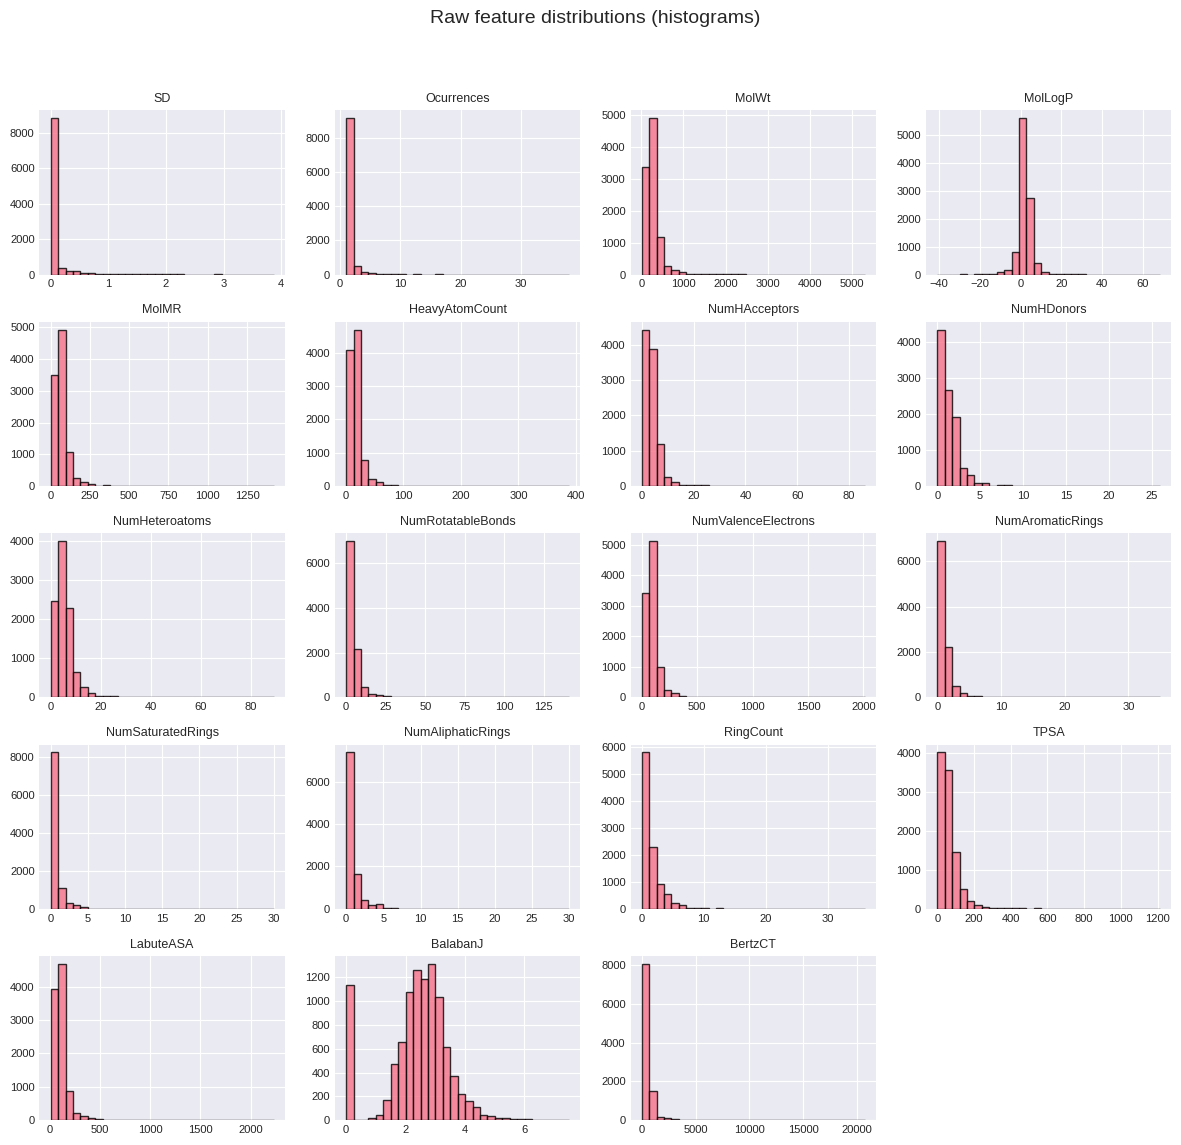

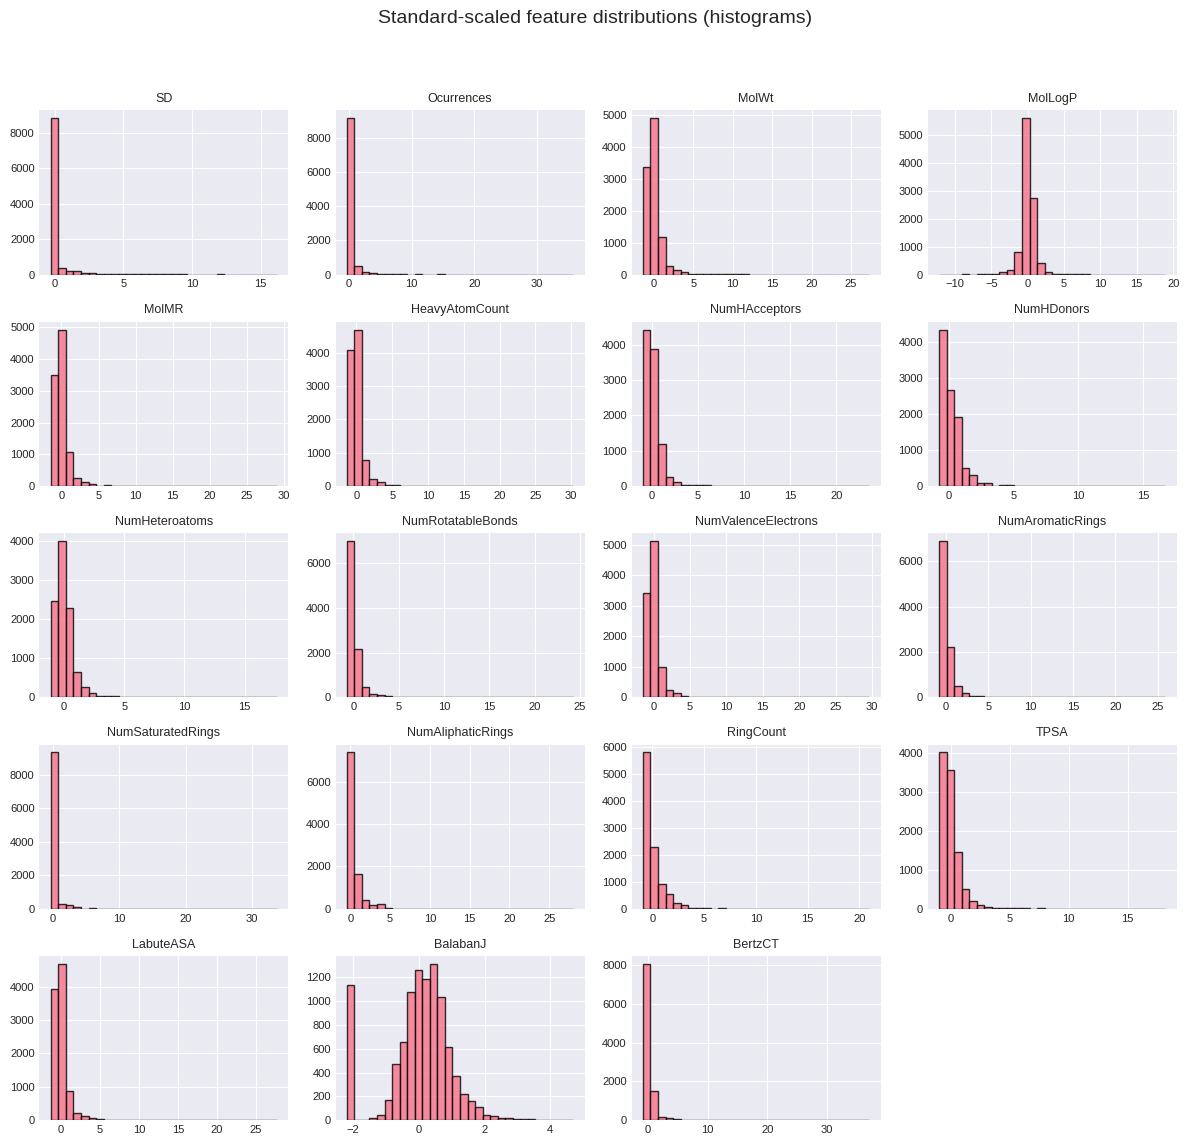

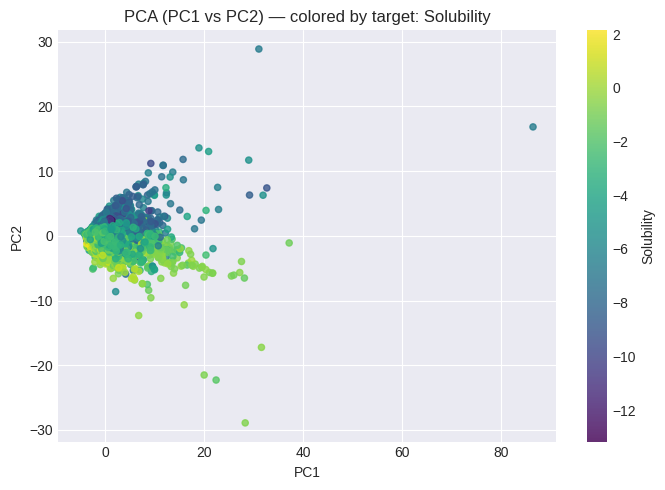

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Ensure your names match (from your script)
features = all_descriptors.copy()
target = target_col

# Helper to plot many subplots (histograms)
def plot_feature_grid(data, feature_names, title, ncols=4, figsize_scale=3):
    n = len(feature_names)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * figsize_scale, nrows * (figsize_scale * 0.8)))
    axes = axes.flatten()
    for i, feat in enumerate(feature_names):
        ax = axes[i]
        vals = data[feat].dropna()
        if vals.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_title(feat)
            continue
        ax.hist(vals, bins=30, alpha=0.8, edgecolor='black')
        ax.set_title(feat, fontsize=9)
        ax.tick_params(axis='both', which='major', labelsize=8)
    # hide unused axes
    for j in range(n, len(axes)):
        axes[j].axis('off')
    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig, axes

# 1) Raw feature histograms
fig1, ax1 = plot_feature_grid(df, features, title="Raw feature distributions (histograms)")

# 2) Standard-scaled feature histograms
scaler = StandardScaler()
X = df[features].values
# some features may have NaNs; scale only rows without NaNs (simple approach)
mask = np.isnan(X).any(axis=1)
if mask.all():
    raise ValueError("All rows contain NaNs in the feature set; can't scale.")
X_nonan = X[~mask]
scaled_nonan = scaler.fit_transform(X_nonan)
# build a scaled dataframe aligned to non-NaN rows
df_scaled = df.loc[~mask, features].copy()
df_scaled.loc[:, :] = scaled_nonan

fig2, ax2 = plot_feature_grid(df_scaled, features, title="Standard-scaled feature distributions (histograms)")

# 3) PCA scatter (first 2 PCs) using scaled data (drop rows with NaNs in features or target)
pca = PCA(n_components=2, random_state=RANDOM_STATE if 'RANDOM_STATE' in globals() else 0)
pcs = pca.fit_transform(scaled_nonan)
# prepare color by target; align with the rows used above
y_for_pca = df.loc[~mask, target].values

fig3, ax3 = plt.subplots(1, 1, figsize=(7, 5))
sc = ax3.scatter(pcs[:, 0], pcs[:, 1], c=y_for_pca, cmap='viridis', s=20, alpha=0.8)
ax3.set_xlabel("PC1")
ax3.set_ylabel("PC2")
ax3.set_title("PCA (PC1 vs PC2) — colored by target: " + target)
plt.colorbar(sc, label=target, ax=ax3)
plt.tight_layout()

# Optionally show explained variance
explained = pca.explained_variance_ratio_
print(f"Explained variance ratio — PC1: {explained[0]:.3f}, PC2: {explained[1]:.3f}")

# Save figures (optional)
fig1.savefig("raw_features_histograms.png", dpi=150, bbox_inches="tight")
fig2.savefig("scaled_features_histograms.png", dpi=150, bbox_inches="tight")
fig3.savefig("pca_pc1_pc2.png", dpi=150, bbox_inches="tight")

plt.show()
